#Free energy diagrams: ideal catalyst, optimal catalysts and cases from the literature

This notebook builds physical intuition by working through a progression of cases, from idealized theory to real literature catalysts. It starts with the perfect catalyst, where the four ORR steps are exactly equally spaced at 1.23 eV each and the overpotential is zero by construction. It then introduces the concept of the reorganization energy β, which quantifies how much the OOH*-O*-OH* intermediate energies deviate from the ideal symmetric arrangement, and shows how a realistic value of β around 3.0 to 3.2 eV produces a minimum achievable overpotential of roughly 0.27 to 0.37 V. The remaining sections apply the same diagram to four real systems from the literature: Au(111), which binds oxygen intermediates too weakly and shows a large overpotential; Pt(111), the benchmark metal surface closest to the volcano peak; and iron and cobalt phthalocyanines (FePc, CoPc), molecular catalysts for which both the associative and dissociative ORR pathways are compared.

Imported libraries

In [ ]:
#########################
##-Importing libraries-##
#########################

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

Plotting parameters

In [ ]:
l = 8.25/2.54 ##-inches
plt.rc('figure',figsize=(l,l)) ##-figure size
plt.rc('figure',      dpi=100) ##-figure dpi
plt.rc('lines',  linewidth=4)  ##-linewidth
plt.rc('font',        size=10) ##-fontsize of the text
plt.rc('font', family='sans-serif') ##-font family
plt.rc('axes',   titlesize=10) ##-fontsize of the axes title
plt.rc('axes',   labelsize=9)  ##-fontsize of the x and y labels
plt.rc('xtick',  labelsize=8)  ##-fontsize of the tick labels
plt.rc('ytick',  labelsize=8)  ##-fontsize of the tick labels
plt.rc('legend', fontsize =8)  ##-fontsize of the legend
plt.rc('figure', titlesize=10) ##-fontsize of the figure title
##-Tol's color scheme
colors = ['#1965B0', '#7BAFDE', '#90C987', '#F1932D', '#DC050C']

Plotting function

In [ ]:
def plot_at_U(U, Es, color='#0000cc', metal='Pt', peroxide=False):
  if not (('plt' in sys.modules) and ('plt' in dir())):
    print('Import matplotlib.pyplot as plt first')
    return

  states = [
    4.92 - 4 * U,
    Es[0] - 3 * U,
    Es[1] - 2 * U,
    Es[2] - 1 * U,
    0
  ]

  ##-Thick horizontal lines, denoting energy levels
  plt.plot([-0.2, 0.2], [states[0], states[0]], c=f'{color}', linestyle='-', linewidth=3, label=f'{metal}, $U$={U} V')
  plt.plot([ 0.8, 1.2], [states[1], states[1]], c=f'{color}', linestyle='-', linewidth=3)
  plt.plot([ 1.8, 2.2], [states[2], states[2]], c=f'{color}', linestyle='-', linewidth=3)
  plt.plot([ 2.8, 3.2], [states[3], states[3]], c=f'{color}', linestyle='-', linewidth=3)
  plt.plot([ 3.8, 4.2], [states[4], states[4]], c=f'{color}', linestyle='-', linewidth=3)

  ##-Thin slanted dotted lines, connecting the energy levels of an energy path
  plt.plot([0.2, 0.8], [states[0], states[1]], c=f'{color}', linestyle=':', linewidth=1)
  plt.plot([1.2, 1.8], [states[1], states[2]], c=f'{color}', linestyle=':', linewidth=1)
  plt.plot([2.2, 2.8], [states[2], states[3]], c=f'{color}', linestyle=':', linewidth=1)
  plt.plot([3.2, 3.8], [states[3], states[4]], c=f'{color}', linestyle=':', linewidth=1)

  if peroxide:
    #plt.plot([0.8, 1.2], [states[1], states[1]], c='#DC050C', linestyle='-', linewidth=3, alpha=1, zorder=10)
    plt.plot([1.2, 1.8], [states[1], 4.92 - 0.68 * 2 - 2 * U], c='#DC050C', linestyle=':', linewidth=1, zorder=10) ##-Thin slanting dotted line, connecting the second species to this elevated peroxide level
    plt.plot([1.8, 2.2], [4.92 - 0.68 * 2 - 2 * U, 4.92 - 0.68 * 2 - 2 * U], c='#DC050C', linestyle='-', linewidth=3, alpha=1, zorder=10) ##-Thick horizontal line of the peroxide level, zorder=10 means on top of everything else


For an ideal catalyst, all elementary steps are equally spaced and downhill at the equilibrium potential, meaning the overpotential is exactly zero. The adsorption free energies are set to multiples of 1.23 V, perfectly distributing the total 4.92 eV across the four steps.

0.0 V


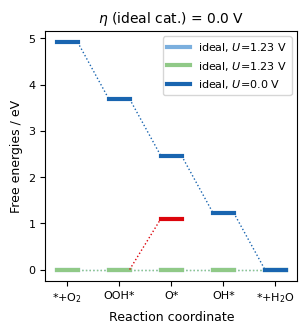

In [ ]:
Es = [3.69, 2.46, 1.23] ##-Question: What do these numbers mean? 1.23 must be the theoretical oxygen reduction potential, and these are the multiples of it (incl. 4.92). Thus, differences between these energies always correspond to the theoretical (ideal) reduction potential.

##-Plotting the diagram
plt.figure() ##-We are plotting multiple free energy level series on a single diagram

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2) ##-This is a single value
print(f'{UL} V')
##-Question: What is this? Just a boilerplate?

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'ideal')
plot_at_U(1.23-UL, Es, colors[2], 'ideal', True)
plot_at_U(0.00, Es, colors[0], 'ideal')

plt.title(f'$\\eta$ (ideal cat.) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O']) ##-Question: Why do we have + after *? Does not * mean adsorbed state? Why do we need + here?

plt.legend()
plt.show()

A real catalyst cannot achieve perfect spacing. The reorganization energy β describes how far the intermediate energies deviate from the ideal case. Here we use β = 3.2 eV, which is physically realistic for ORR-type reactions, to model an optimal but imperfect catalyst. The resulting overpotential is 0.37 V.

0.37 V


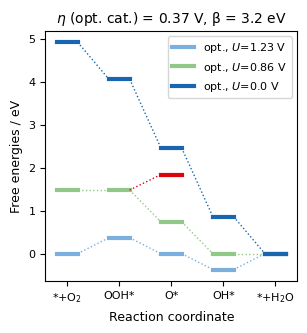

In [ ]:
beta = 3.2
centrum = 2.46 ##-Twice the ideal value of oxygen reduction potential
Es = [centrum + beta/2, centrum, centrum - beta/2]

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'opt.')
plot_at_U(1.23-UL, Es, colors[2], 'opt.', True)
plot_at_U(0.00, Es, colors[0], 'opt.')
print(f'{UL} V')

plt.title(f'$\\eta$ (opt. cat.) = {UL} V, β = 3.2 eV')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

Reducing β to 3.0 eV brings the intermediate energies closer together, lowering the overpotential further to 0.27 V and illustrating how a more balanced energy landscape improves catalytic performance.

0.27 V


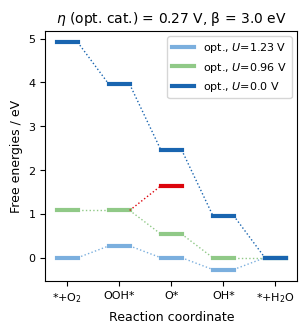

In [ ]:
beta = 3.0
centrum = 2.46
Es = [centrum + beta/2, centrum, centrum - beta/2]

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potential
plot_at_U(1.23, Es, colors[1], 'opt.')
plot_at_U(1.23-UL, Es, colors[2], 'opt.', True)
plot_at_U(0.00, Es, colors[0], 'opt.')
print(f'{UL} V')

plt.title(f'$\\eta$ (opt. cat.) = {UL} V, β = 3.0 eV')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

We now move from theoretical constructs to real catalysts from the literature. Au(111) binds oxygen intermediates weakly, which shifts the free energy landscape and results in a limiting potential of 0.42 V and an overpotential of 0.81 V.

From http://dx.doi.org/10.1021/cs300227s

0.81 V


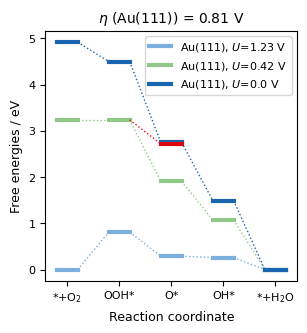

In [ ]:
Es = [4.50, 2.75, 1.49] ##-Question: Energties here are not symmetrical. How is this related to the energy set for the ideal catalyst?

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'Au(111)')
plot_at_U(round(1.23-UL,2), Es, colors[2], 'Au(111)', True)
plot_at_U(0.00, Es, colors[0], 'Au(111)')
print(f'{UL} V')

plt.title(f'$\\eta$ (Au(111)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

Pt(111) is the most studied ORR catalyst and the closest real material to the top of the volcano. Its hexagonal close-packed surface exposes top, bridge, fcc-hollow, and hcp-hollow adsorption sites. The resulting overpotential of 0.54 V is significantly lower than Au(111), reflecting stronger and better-balanced intermediate binding.

0.69 V


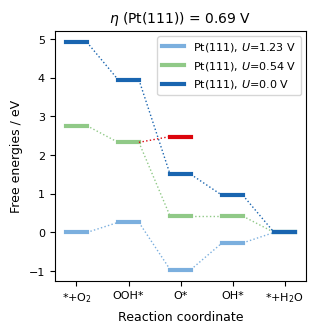

In [ ]:
Es = [3.95, 1.5, 0.96]

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'Pt(111)')
plot_at_U(1.23-UL, Es, colors[2], 'Pt(111)', True)
plot_at_U(0.00, Es, colors[0], 'Pt(111)')
print(f'{UL} V')

plt.title(f'$\\eta$ (Pt(111)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()


Iron phthalocyanine (FePc) is a synthetic macrocyclic complex with an Fe center coordinated by four isoindole nitrogen atoms. Unlike metallic surfaces, molecular catalysts like FePc can follow either an associative mechanism, proceeding through OOH*, or a dissociative mechanism where O₂ splits directly. We plot both to compare their overpotentials.

0.23 V


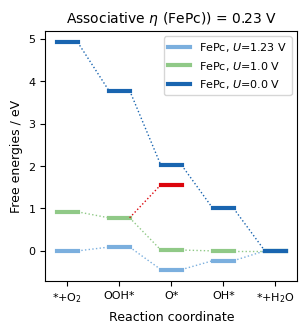

In [ ]:
Es = [3.78, 2.02, 1.00]

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'FePc')
plot_at_U(1.23-UL, Es, colors[2], 'FePc', True)
plot_at_U(0.00, Es, colors[0], 'FePc')
print(f'{UL} V')

plt.title(f'Associative $\\eta$ (FePc)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

0.23 V


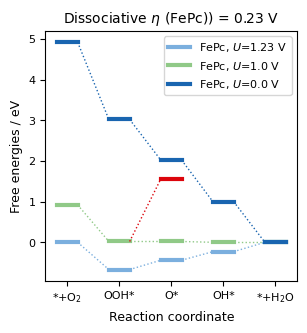

In [ ]:
Es = [1.00+2.02, 2.02, 1.00]

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'FePc')
plot_at_U(1.23-UL, Es, colors[2], 'FePc', True)
plot_at_U(0.00, Es, colors[0], 'FePc')
print(f'{UL} V')

plt.title(f'Dissociative $\\eta$ (FePc)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

Cobalt phthalocyanine (CoPc) shares the same macrocyclic framework as FePc but with Co(II) at the center. The change in metal shifts the d-band center and weakens oxygen binding relative to FePc, placing CoPc closer to the peak of the ORR volcano. As with FePc, we compare the associative and dissociative pathways.

0.27 V


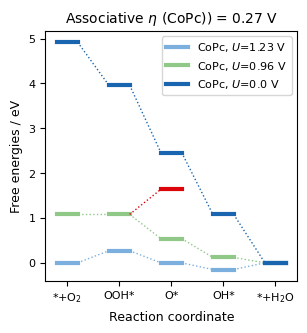

In [ ]:
Es = [1.23*3+0.27, 2.46, 1.23-0.15] ##-from doi.org/10.1002/cssc.202100182

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'CoPc')
plot_at_U(1.23-UL, Es, colors[2], 'CoPc', True)
plot_at_U(0.00, Es, colors[0], 'CoPc')
print(f'{UL} V')

plt.title(f'Associative $\\eta$ (CoPc)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

The dissociative mechanism skips OOH: O₂ splits directly to 2O and is reduced into O and OH

0.15 V


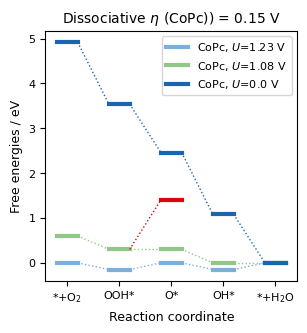

In [ ]:
Es = [2.46+1.23-0.15, 2.46, 1.23-0.15] ##-from doi.org/10.1002/cssc.202100182

##-Plotting the diagram
plt.figure()

##-Define the energies list for plotting
UL = round(1.23-min((4.92-Es[0], Es[0]-Es[1], Es[1]-Es[2], Es[2])),2)

##-Plot for different potentials
plot_at_U(1.23, Es, colors[1], 'CoPc')
plot_at_U(1.23-UL, Es, colors[2], 'CoPc', True)
plot_at_U(0.00, Es, colors[0], 'CoPc')
print(f'{UL} V')

plt.title(f'Dissociative $\\eta$ (CoPc)) = {UL} V')
plt.xlabel('Reaction coordinate')
plt.ylabel('Free energies / eV')
plt.xticks([0, 1, 2, 3, 4], ['*+O$_2$', 'OOH*', 'O*', 'OH*', '*+H$_2$O'])

plt.legend()
plt.show()

#Summary

After completing this notebook, you should be able to:

1. Interpret free energy diagrams. Read a CHE free energy diagram at any applied potential, identify which elementary step is rate-limiting (the largest uphill step at the equilibrium potential), and extract the limiting potential and overpotential directly from the diagram.
2. Construct the ideal and optimal catalyst cases. Set intermediate energies to exact multiples of 1.23 eV to produce a zero-overpotential ideal catalyst, then introduce the reorganization energy β to model a realistic symmetric catalyst and understand why a finite minimum overpotential is unavoidable for the ORR given the known OOH*/OH* scaling relation.
3. Understand the effect of β on performance. Recognize that decreasing β brings OOH* and OH* energies closer together, flattening the step height distribution and lowering the overpotential, and that β values around 3.0 to 3.2 eV represent the physically accessible range for transition metal catalysts.
Interpret real catalyst diagrams from the literature.
4. Compare associative and dissociative ORR pathways. For molecular catalysts such as FePc and CoPc, construct both the associative pathway (proceeding through OOH*) and the dissociative pathway (where O₂ splits directly to two O atoms), plot each separately, and compare their overpotentials to determine which mechanism is thermodynamically preferred.
5. Use the plot_at_U() function. Call the plotting function for three reference potentials (0 V, 1.23 V, and the limiting potential) on a single figure, read the 4.92 eV total energy span as four times the equilibrium potential, and correctly assign the n*U shifts to each intermediate state.